# Milestone 4: Alternative Models

## Detection of Hydroxychloroquine Macular Toxicity via OCT Images

Proyecto Integrador - TC5035.10

Team 45

Tecnológico de Monterrey

Sponsor: Dr. Alejandro Rodríguez García, Hospital Zambrano Hellion
Date: May 2026

Team members:

- Natalia Nevarez Tinoco - A01566204
- Alejandro Caamaño Granados - A00843392
- Diana Jimena López Nájera

## 0. Google Drive Setup

Same Drive layout as M3. This notebook reads the M2 processed-image export (`OCT_Dataset_Limpio_cropped`) and the HCQuery checkpoint (`hcquery_model.pt`).

In [ ]:
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')

EXPECTED = ('/content/drive/MyDrive/Colab Notebooks/MNA/'
            'Proyecto Integrador/Avance4/OCT_Dataset_Limpio_cropped')

data_root = None
if Path(EXPECTED).exists():
  data_root = Path(EXPECTED)

else:
  matches = []
  for root, dirs, files in os.walk('/content/drive/MyDrive', followlinks=True):
    if Path(root).name == 'OCT_Dataset_Limpio_cropped':
      dris_low = [d.lower() for d in dirs]
      if 'no' in dirs_low and 'si' in dirs_low:
        matches.append(Path(root))
  for m in matches:
    if 'Avance4' in str(m):
      data_root = m
      break
  if data_root is None and matches:
    data_root = matches[0]

if data_root is not None:
  actual = {d.lower(): d for d in os.listdir(data_root)}
  NO_DIR = data_root / actual['no']
  SI_DIR = data_root / actual['si']
  print(f'Processed dataset found at: {data_root}')
  print(f'  No: {len(list(NO_DIR.iterdir()))} files')
  print(f'  Si: {len(list(SI_DIR.iterdir()))} files')
else:
  print('ERROR: no dataset found')

HCQUERY_MODEL_PATH = ('/content/drive/MyDrive/Colab Notebooks/MNA/'
                     'Proyecto Integrador/Avance4/hcquery_model.pt')

if Path(HCQUERY_MODEL_PATH).exists():
  print(f'HCQuery model found: {HCQUERY_MODEL_PATH}')
  HCQ_AVAILABLE = True
else:
  print(f'ERROR: HCQuery model not found at {HCQUERY_MODEL_PATH}')
  HCQ_AVAILABLE = False

Mounted at /content/drive
Processed dataset found at: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance4/OCT_Dataset_Limpio_cropped
  No: 179 files
  Si: 15 files
HCQuery model found: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance4/hcquery_model.pt


## 1. Import Libraries

M4 introduces a few more libraies beyond the one's at M3:

- `optuna`: the hyperparameter optimization framework used in Phase3
- `sklearn.svm.SVC`: the kernel SVM classifier (Models 2 and 5)
- The rest (`torch`, `efficientnet_pytorch`, `sklearn` classical heads, metric functions) was already in M3

In [ ]:
import glob, random, warnings, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, fbeta_score)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as tv_models

# Optuna for hyperparameter tuning
try:
  import optuna
  print('optuna already installed')
except ImportError:
  import subprocess, sys
  subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
  import optuna
  print('optuna installed')


# HCQuery uses the efficientnet_pytorch library
try:
    from efficientnet_pytorch import EfficientNet
    print('efficientnet_pytorch already installed.')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'efficientnet_pytorch', '-q'])
    from efficientnet_pytorch import EfficientNet
    print('efficientnet_pytorch installed.')

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries imported. Compute device: {DEVICE}')

optuna installed
efficientnet_pytorch installed.
Libraries imported. Compute device: cuda


## 2. Load Preprocessed Image Dataset

Same dataset as M3, same parser, same exclusion of the `Sospecha` set. The 12:1 class imbalance and patient-level grouping carry forward as the binding constraints for every modeling deicision in this notebook.

In [ ]:
def parse_patient_id(filepath):
  '''Patient ID is the first underscore-separated token of the filename'''
  stem = Path(filepath).stem
  parts = stem.split('_')
  if stem.startswith('AUTO') and len(parts) > 1:
    return parts[1]
  return parts[0]

records = []
for label_dir, label in [(NO_DIR, 'no'), (SI_DIR, 'si')]:
  for fp in label_dir.iterdir():
    if fp.suffix.lower() in ('.png', '.jpg', '.jpeg'):
      records.append({
          'filepath': str(fp),
          'label': label,
          'label_enc': 0 if label == 'no' else 1,
          'patient_id': parse_patient_id(fp),})

df = pd.DataFrame(records).reset_index(drop=True)
print(f'Total processed images: {len(df)}')
print(df['label'].value_counts().rename('count'))
print(f'Unique patients: {df['patient_id'].nunique()}')

# Patient-grouped CV setup - shared across the entire notebook
y = df['label_enc'].values
groups = df['patient_id'].values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'\nClass imbalance: {(y==0).sum()}:{(y==1).sum()} '
      f'({(y==0).sum()/max((y==1).sum(),1):.1f}:1)')


Total processed images: 194
label
no    179
si     15
Name: count, dtype: int64
Unique patients: 69

Class imbalance: 179:15 (11.9:1)


## 3. Milestone 4 Modeling Strategy

### 3.1 The Seven Model Lineup

M3 established that the domain-specific HCQuery backbone (PR-AUC 0.452 zero-shot) outperforms the generic ResNet18 backbone (PR-AUC 0.290), and that head fine-tuning hurts at this dataset size. M4 builds on those findings with the **feature-extractor + classical head** pattern that Dr. Rodríguez García's own 2021 corneal paper (Bustamante-Arias et al., 2021) used as its primary design.

Seven individual models are built (none of them ensembles). They are organized along a single axis (feature source x classifier head), so the coparison is coherent.

| # | Feature source | Classifier head | Role |
|---|---|---|---|
| **1** | HCQuery (EfficientNet-b4, OCT-pretrained) | Logistic Regression | Linear, interpretable contender |
| **2** | HCQuery | SVM (RBF kernel) | Direct replication of sponsor's 2021 pattern |
| **3** | HCQuery | Random Forest | Nonlinear, robust contender |
| **4** | ResNet18 (ImageNet-pretrained) | Logistic Regression | Generic-backbone control |
| **5** | ResNet18 | SVM (RBF kernel) | Generic-backbone control |
| **6** | End-to-end | HCQuery, full fine-tune | Reference: ignores M3 small-data lesson |
| **7** | End-to-end | HCQuery, partial fine-tune (last block) | Reference: M3 Tier 2c, re-evaluated |

The logic is:

- **Models 1-3** keep the strongest M3 feature extractor fixed and vary the classifier across three genuinely different algorithm families (linear, kernel/margin, tree ensemble). This is where the rubric's "algoritmos variados" requirement is satisfied.
- **Models 4-5** swap HCQuery for ResNet18 with two of the same classifiers. This isolates whether any gain comes from the backbone or the head - without this control, a reviewer can argue the classifier is doing the work.
- **Models 6-7** are end-to-end fine-tuning references. M3 showed both that head-only fine-tuning underperforms zero-shot and that partial fine-tuning underperforms further. M4 confirms whether full and partial fine-tuning behave the same way under a more careful evaluation. If they continue to underperform, the M3 small-data finding is reinforced; if they suddenly beat the feature extractors, the M3 conclusion needs revision.

### 3.2 Evaluation Protocol

The protocol from M3 carries over without modification.

- **Patient-grouped 5-fold CV** via `StratifiedGroupKFold`. No patient appears in both train and validation of any fold.
- **Primary metric: PR-AUC** (average precision on the Si class). Thershold-independent, robust to our 12:1 imbalance.
- **Secondary metric: F2-score on the Si class**. Beta=2 weights recall more than precision, matching the screening priority.
- **Headline clinical metric: Si-class Recall**. The fraction of true toxicity cases caught.
- **Reported alongside**: Si-class precision (false-alarm cost) and training time (for the rubric's required comparison).

Accuracy is reported only for transparenct. It remains not useful as a selection metric at 12:1 imbalance.

### 3.3 Workflow

The notebook follows the four-phase plan agreed with the team:

1. **Phase 1 - Build** (Section 5): All seven models with default hyperparameters and the M3 patient-grouped CV.
2. **Phase 2 - Compare** (Section 6): Sorted results table with at least three metrics + training time. Select the top two.
3. **Phase 3 - Tune** (Section 7): Optuna-based hyperparameter search (~50-100 trials per model) on the top two, using PR-AUC as the objective.
4. **Phase 4 - Select** (Section 8): Final individual model. Justified on PR-AUC, F2, Si-recall, interpretability, training cost, and robustness to the storage-fingerprint confounder identified in M2.

## 4. Feature Extraction

Models 1-5 use a pretrained CNN as a frozen feature extractor. To avoid recomputing those features inside every cross-validation fold, both HCQuery and ResNet18 features are extracted once per image and cached. The classical classifiers then train on these cached arrays in seconds.

The feature vector is the *pre-classifier* representation:

- **HCQuery EfficientNet-b4**: 1792-d output of the global pooling layer.
- **ResNet18**: 512-d output of the global pooling layer.

### 4.1 Shared Preprocessing

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_eval_transform(img_size):
  '''Evaluation transform only, no augmentation during feature extraction'''
  return transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
      transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
  ])

class OCTDatasetRGB(Dataset):
  '''Loads images as RGB, compatible with both backbones'''
  def __init__(self, frame, transform):
    self.frame = frame.reset_index(drop=True)
    self.transform = transform
  def __len__(self):
    return len(self.frame)
  def __getitem__(self, i):
    row = self.frame.iloc[i]
    img = Image.open(row['filepath']).convert('RGB')
    return self.transform(img), torch.tensor(row['label_enc'],
                                             dtype=torch.float32)

print('Shared dataset class defined.')

Shared dataset class defined.


### 4.2 Extract HCQuery Features (1792-d)

In [ ]:
assert HCQ_AVAILABLE, 'hcquer_model.pt not found. Update HCQUERY_MODEL_PATH'

IMG_SIZE_HCQ = 256

raw_sd = torch.load(HCQUERY_MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict_hcq = {k.partition('module.')[2]: v for k, v in raw_sd.items()}

hcq_full = EfficientNet.from_name('efficientnet-b4')
hcq_full._fc = nn.Linear(hcq_full._fc.in_features, 2)
hcq_full.load_state_dict(state_dict_hcq)
hcq_full.to(DEVICE).eval()
print(f'HCQuery loaded. Parameters: {sum(p.numel() for p in hcq_full.parameters()):,}')

# Extract pre-classifier features (1792-d)
eval_tf_hcq = make_eval_transform(IMG_SIZE_HCQ)
loader = DataLoader(OCTDatasetRGB(df, eval_tf_hcq),
                    batch_size=16, shuffle=False)

hcq_features = []
with torch.no_grad():
  for x, _ in loader:
    x = x.to(DEVICE)
    # Mirror EfficientNet's forward, but stop before _fc
    feats = hcq_full.extract_features(x)
    feats = hcq_full._avg_pooling(feats).flatten(start_dim=1)
    hcq_features.append(feats.cpu().numpy())

X_hcq = np.vstack(hcq_features)
print(f'HCQuery features extracted: {X_hcq.shape}')

HCQuery loaded. Parameters: 17,552,202
HCQuery features extracted: (194, 1792)


### 4.3 Extract ResNet18 Features (512-d)

In [ ]:
IMG_SIZE_RN = 224

resnet_full = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
# Replace the final fc with identity to expose the 512-d pooled features
resnet_full.fc = nn.Identity()
resnet_full.to(DEVICE).eval()
print(f'ResNet18 loaded. Parameters: {sum(p.numel() for p in resnet_full.parameters()):,}')

eval_tf_rn = make_eval_transform(IMG_SIZE_RN)
loader_rn = DataLoader(OCTDatasetRGB(df, eval_tf_rn),
                       batch_size=16, shuffle=False)

rn_features = []
with torch.no_grad():
  for x, _ in loader_rn:
    x = x.to(DEVICE)
    feats = resnet_full(x)
    rn_features.append(feats.cpu().numpy())

X_rn = np.vstack(rn_features)
print(f'ResNet18 features extracted: {X_rn.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.5MB/s]


ResNet18 loaded. Parameters: 11,176,512
ResNet18 features extracted: (194, 512)


> **Note on feature dimensionality**. HCQuery (1792-d) has more than 3x the features of ResNet18 (512-d) and approximately the same number of samples (194). The classical heads in Section 5 therefore included `StandardScaler` and rely on L2 regularization (LogReg) or kernel methods (SVM) to handle the high-dimensional, low-sample regime.

## 5. Phase 1 - Build All 7 Models

Each model is trained with default hyperparameters inside the same patient-grouped 5-fold CV used in M3. The five feature-extractor models (1-5) train classical heads on cached features and complete in seconds. The two end to end fine tune models (6-7) train an EfficientNet-b4 per fold and take longer.

A single `evaluate_model` helper handles the classical case (sklearn pipeline + OOF predictions), and a separate `evaluate_finetune` helper handles the CNN case. Both return identical metric dictionaries so the comparison in Section 6 is uniform.

### 5.1 Shared Evaluation Helpers

In [ ]:
def metrics_from_oof(name, y_true, y_pred, y_score, train_time,
                     n_params=None):
  '''Standard metric dict, shared across all seven models'''
  return {
      'model': name,
      'accuracy': (y_pred == y_true).mean(),
      'recall_Si': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
      'prec_Si': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
      'f2_Si': fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
      'pr_auc': average_precision_score(y_true, y_score),
      'train_time_s': train_time,
      'n_params': n_params,}

def evaluate_classical(name, build_pipeline_fn, X, y, groups, cv):
  '''
  Run patient-grouped CV with a sklearn pipeline
  build_pipeline_fn: callable that returns a fresh sklearn Pipeline
  Returns metric dict and per-fold OOF arrays
  '''
  oof_pred = np.zeros(len(y), dtype=int)
  oof_score = np.zeros(len(y), dtype=float)
  t0 = time.time()
  for tr, va in cv.split(X, y, groups):
    pipe = build_pipeline_fn()
    pipe.fit(X[tr], y[tr])
    oof_pred[va] = pipe.predict(X[va])
    # All three classifiers support predict_proba
    oof_score[va] = pipe.predict_proba(X[va])[:, 1]
  train_time = time.time() - t0
  return metrics_from_oof(name, y, oof_pred, oof_score, train_time), oof_pred, oof_score

print('Classical evaluation helper defined')

Classical evaluation helper defined


### 5.2 Models 1-3 HCQuery + Classical Heads

In [ ]:
results = []
oof_store = {} # keep OOF predictions for confusion matrices later

# Model 1: HCQuery + LogReg
def build_m1():
  return Pipeline([
      ('scaler', StandardScaler()),
      ('clf', LogisticRegression(class_weight='balanced',
                                 max_iter=2000,
                                 random_state=RANDOM_STATE),)
  ])

m1_metrics, m1_pred, m1_score = evaluate_classical(
    'M1: HCQ + LogReg', build_m1, X_hcq, y, groups, sgkf)
results.append(m1_metrics)
oof_store['M1: HCQ + LogReg'] = (m1_pred, m1_score)
print(f'Model 1 done in {m1_metrics["train_time_s"]:.2f}s | '
      f'PR-AUC {m1_metrics["pr_auc"]:.3f} | F2 {m1_metrics["f2_Si"]:.3f}')

# Model 2: HCQuery + SVM (RBF)
def build_m2():
  return Pipeline([
      ('scaler', StandardScaler()),
      ('clf', SVC(kernel='rbf', class_weight='balanced',
                  probability=True, random_state=RANDOM_STATE)),
  ])

m2_metrics, m2_pred, m2_score = evaluate_classical(
    'M2: HCQ + SVM', build_m2, X_hcq, y, groups, sgkf)
results.append(m2_metrics)
oof_store['M2: HCQ + SVM'] = (m2_pred, m2_score)
print(f'Model 2 done in {m2_metrics["train_time_s"]:.2f}s | '
      f'PR-AUC {m2_metrics["pr_auc"]:.3f} | F2 {m2_metrics["f2_Si"]:.3f}')

# Model 3: HCQuery + RF
def build_m3():
    return Pipeline([
        ('scaler', StandardScaler()),  # not strictly needed for RF but kept for consistency
        ('clf', RandomForestClassifier(n_estimators=300,
                                        class_weight='balanced',
                                        random_state=RANDOM_STATE,
                                        n_jobs=-1)),
    ])

m3_metrics, m3_pred, m3_score = evaluate_classical(
    'M3: HCQ + RF', build_m3, X_hcq, y, groups, sgkf)
results.append(m3_metrics)
oof_store['M3: HCQ + RF'] = (m3_pred, m3_score)
print(f'Model 3 done in {m3_metrics["train_time_s"]:.2f}s | '
      f'PR-AUC {m3_metrics["pr_auc"]:.3f} | F2 {m3_metrics["f2_Si"]:.3f}')

print('\nHCQuery row complete.')
pd.DataFrame(results).round(3)

Model 1 done in 0.74s | PR-AUC 0.131 | F2 0.000
Model 2 done in 0.99s | PR-AUC 0.158 | F2 0.000
Model 3 done in 9.95s | PR-AUC 0.117 | F2 0.000

HCQuery row complete.


,model,accuracy,recall_Si,prec_Si,f2_Si,pr_auc,train_time_s,n_params
0,M1: HCQ + LogReg,0.912,0.0,0.0,0.0,0.131,0.736,None
1,M2: HCQ + SVM,0.918,0.0,0.0,0.0,0.158,0.990,None
2,M3: HCQ + RF,0.923,0.0,0.0,0.0,0.117,9.947,None


### 5.3 Models 4 & 5: ResNet18 + Classical Heads (Generic-Backbone Control)

In [ ]:
# Model 4: ResNet18 + LogReg
def build_m4():
  return Pipeline([
      ('scaler', StandardScaler()),
      ('clf', LogisticRegression(class_weight='balanced',
                                 max_iter=2000,
                                 random_state=RANDOM_STATE)),
  ])

m4_metrics, m4_pred, m4_score = evaluate_classical(
    'M4: ResNet + LogReg', build_m4, X_rn, y, groups, sgkf)
results.append(m4_metrics)
oof_store['M4: ResNet + LogReg'] = (m4_pred, m4_score)
print(f'Model 4 done in {m4_metrics["train_time_s"]:.2f}s | '
      f'PR-AUC {m4_metrics["pr_auc"]:.3f} | F2 {m4_metrics["f2_Si"]:.3f}')

# Model 5: ResNet18 + SVM
def build_m5():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced',
                    probability=True, random_state=RANDOM_STATE)),
    ])

m5_metrics, m5_pred, m5_score = evaluate_classical(
    'M5: ResNet + SVM', build_m5, X_rn, y, groups, sgkf)
results.append(m5_metrics)
oof_store['M5: ResNet + SVM'] = (m5_pred, m5_score)
print(f'Model 5 done in {m5_metrics["train_time_s"]:.2f}s | '
      f'PR-AUC {m5_metrics["pr_auc"]:.3f} | F2 {m5_metrics["f2_Si"]:.3f}')

print('\nResNet18 row complete.')
pd.DataFrame(results).round(3)

Model 4 done in 1.07s | PR-AUC 0.061 | F2 0.000
Model 5 done in 0.57s | PR-AUC 0.053 | F2 0.000

ResNet18 row complete.


,model,accuracy,recall_Si,prec_Si,f2_Si,pr_auc,train_time_s,n_params
0,M1: HCQ + LogReg,0.912,0.0,0.0,0.0,0.131,0.736,None
1,M2: HCQ + SVM,0.918,0.0,0.0,0.0,0.158,0.990,None
2,M3: HCQ + RF,0.923,0.0,0.0,0.0,0.117,9.947,None
3,M4: ResNet + LogReg,0.876,0.0,0.0,0.0,0.061,1.066,None
4,M5: ResNet + SVM,0.923,0.0,0.0,0.0,0.053,0.566,None


### 5.4 End-to-End Fine-Tuning Infraestructure

Models 6 and 7 need the augmentation pipeline, balanced sampler, trained loop, and pooled-CV runner from M3. Only differences between the two models are which parameters are unfrozen inside `build_fn`.

In [ ]:
class RandomGaussianNoise(nn.Module):
    '''Subtle Gaussian noise, reproduced from M2 Section 8.'''
    def __init__(self, min_std=0.01, max_std=0.03):
        super().__init__()
        self.min_std, self.max_std = min_std, max_std
    def forward(self, t):
        std = torch.empty(1).uniform_(self.min_std, self.max_std).item()
        return torch.clamp(t + torch.randn_like(t) * std, 0.0, 1.0)

def make_train_transform(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.06, 0.06),
                                 scale=(0.92, 1.08), shear=4),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),
        RandomGaussianNoise(0.01, 0.03),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def make_balanced_sampler(train_frame):
    '''
    WeightedRandomSampler that draws Si images ~50% of each epoch.
    M3 cell 71 (Open Issue 3) flagged that stacking WeightedRandomSampler
    AND pos_weight pushed the model too aggressively toward Si.
    In M4 we keep the sampler but DROP pos_weight in the loss (set to 1.0).
    '''
    labels = train_frame['label_enc'].values
    class_count = np.bincount(labels, minlength=2)
    class_weight = 1.0/np.maximum(class_count, 1)
    sample_weight = class_weight[labels]
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weight, dtype=torch.double),
        num_samples=len(labels),
        replacement=True)

def train_cnn(model, train_loader, val_loader, train_frame,
              epochs=20, lr=1e-4, weight_decay=1e-4, patience=5,
              verbose=False):
    '''Train one fold. Drops pos_weight per M3 cell 71 issue #3.'''
    criterion = nn.BCEWithLogitsLoss()  # no pos_weight - sampler handles imbalance
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'val_recall': []}
    best_val, best_state, best_epoch, no_improve = float('inf'), None, 1, 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, yb in train_loader:
            x, yb = x.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x).squeeze(1), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vrunning, y_true, y_pred = 0.0, [], []
        with torch.no_grad():
            for x, yb in val_loader:
                x, yb = x.to(DEVICE), yb.to(DEVICE)
                logits = model(x).squeeze(1)
                vrunning += criterion(logits, yb).item() * x.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).int()
                y_true += yb.int().cpu().tolist()
                y_pred += preds.cpu().tolist()
        val_loss = vrunning / len(val_loader.dataset)
        val_recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_recall'].append(val_recall)

        if val_loss < best_val - 1e-4:
            best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
            best_epoch, no_improve = epoch, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return model, history

def predict_cnn(model, loader):
    model.eval()
    scores, trues = [], []
    with torch.no_grad():
        for x, yb in loader:
            x = x.to(DEVICE)
            scores += torch.sigmoid(model(x).squeeze(1)).cpu().tolist()
            trues += yb.int().tolist()
    return np.array(trues), np.array(scores)

def run_finetune_cv(build_fn, img_size, label, epochs=20, lr=1e-4,
                    weight_decay=1e-4, patience=5, verbose=False):
    '''Patient-grouped CV runner for end-to-end fine-tuning.'''
    train_tf = make_train_transform(img_size)
    eval_tf = make_eval_transform(img_size)

    oof_score = np.zeros(len(df), dtype=float)
    oof_pred = np.zeros(len(df), dtype=int)
    t0 = time.time()

    for k, (tr_idx, va_idx) in enumerate(sgkf.split(df, y, groups)):
        tr_frame = df.iloc[tr_idx].reset_index(drop=True)
        va_frame = df.iloc[va_idx].reset_index(drop=True)

        tr_sampler = make_balanced_sampler(tr_frame)
        tr_loader = DataLoader(OCTDatasetRGB(tr_frame, train_tf),
                                batch_size=16, sampler=tr_sampler)
        va_loader = DataLoader(OCTDatasetRGB(va_frame, eval_tf),
                                batch_size=16, shuffle=False)

        model = build_fn()
        model, hist = train_cnn(model, tr_loader, va_loader, tr_frame,
                                 epochs=epochs, lr=lr,
                                 weight_decay=weight_decay, patience=patience,
                                 verbose=verbose)

        va_true, va_score = predict_cnn(model, va_loader)
        oof_score[va_idx] = va_score
        oof_pred[va_idx] = (va_score >= 0.5).astype(int)
        if verbose:
            print(f'  Fold {k}: best epoch {hist["best_epoch"]} | '
                  f'val Si-recall {hist["val_recall"][hist["best_epoch"]-1]:.3f}')

    train_time = time.time() - t0
    return oof_pred, oof_score, train_time

print('Fine-tuning infrastructure ready.')

Fine-tuning infrastructure ready.


### 5.5 Models 6-7 - End to End Fine-Tuning

In [ ]:
def build_m6_full_finetune():
    '''Model 6: HCQuery with the entire backbone unfrozen.'''
    model = EfficientNet.from_name('efficientnet-b4')
    model._fc = nn.Linear(model._fc.in_features, 2)
    model.load_state_dict(state_dict_hcq)
    in_feats = model._fc.in_features
    model._fc = nn.Sequential(
        nn.Linear(in_feats, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 1),
    )
    # All parameters trainable
    for p in model.parameters():
        p.requires_grad = True
    return model.to(DEVICE)

def build_m7_partial_finetune():
    '''Model 7: HCQuery with only the last block + head unfrozen (M3 Tier 2c).'''
    model = EfficientNet.from_name('efficientnet-b4')
    model._fc = nn.Linear(model._fc.in_features, 2)
    model.load_state_dict(state_dict_hcq)
    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False
    # Replace classifier head
    in_feats = model._fc.in_features
    model._fc = nn.Sequential(
        nn.Linear(in_feats, 128),
        nn.ReLU(),
        nn.Dropout(0.6),
        nn.Linear(128, 1),
    )
    # Unfreeze the last EfficientNet block, conv head, BN head, and FC head
    for p in model._blocks[-1].parameters():
        p.requires_grad = True
    for p in model._conv_head.parameters():
        p.requires_grad = True
    for p in model._bn1.parameters():
        p.requires_grad = True
    for p in model._fc.parameters():
        p.requires_grad = True
    return model.to(DEVICE)

# Model 6: Full fine-tune
print('Training Model 6 (HCQ full fine-tune)...')
m6_pred, m6_score, m6_time = run_finetune_cv(
    build_m6_full_finetune, IMG_SIZE_HCQ, 'M6', epochs=15, lr=1e-5,
    weight_decay=1e-3, patience=4, verbose=True)
m6_metrics = metrics_from_oof('M6: HCQ full FT', y, m6_pred, m6_score, m6_time)
results.append(m6_metrics)
oof_store['M6: HCQ full FT'] = (m6_pred, m6_score)
print(f'Model 6 done in {m6_time:.1f}s | PR-AUC {m6_metrics["pr_auc"]:.3f} | '
      f'F2 {m6_metrics["f2_Si"]:.3f}\n')

# Model 7: Partial fine-tune
print('Training Model 7 (HCQ partial fine-tune)...')
m7_pred, m7_score, m7_time = run_finetune_cv(
    build_m7_partial_finetune, IMG_SIZE_HCQ, 'M7', epochs=15, lr=1e-5,
    weight_decay=1e-3, patience=4, verbose=True)
m7_metrics = metrics_from_oof('M7: HCQ partial FT', y, m7_pred, m7_score, m7_time)
results.append(m7_metrics)
oof_store['M7: HCQ partial FT'] = (m7_pred, m7_score)
print(f'Model 7 done in {m7_time:.1f}s | PR-AUC {m7_metrics["pr_auc"]:.3f} | '
      f'F2 {m7_metrics["f2_Si"]:.3f}')

Training Model 6 (HCQ full fine-tune)...
  Fold 0: best epoch 15 | val Si-recall 0.000
  Fold 1: best epoch 9 | val Si-recall 0.000
  Fold 2: best epoch 15 | val Si-recall 0.000
  Fold 3: best epoch 15 | val Si-recall 0.000
  Fold 4: best epoch 15 | val Si-recall 1.000
Model 6 done in 433.3s | PR-AUC 0.423 | F2 0.584

Training Model 7 (HCQ partial fine-tune)...
  Fold 0: best epoch 15 | val Si-recall 0.000
  Fold 1: best epoch 12 | val Si-recall 0.000
  Fold 2: best epoch 15 | val Si-recall 0.000
  Fold 3: best epoch 15 | val Si-recall 0.000
  Fold 4: best epoch 15 | val Si-recall 1.000
Model 7 done in 257.1s | PR-AUC 0.271 | F2 0.402


## 6. Phase 2 Comparison and Top-Two Selection

All seven models are now trained. This section consolidates them into a single comparison table sorted by PR-AUC (primary metric), reports the additional metrics required by the rubric, and selects the two for hyperparameter training.

Table reports five metrics: PR-AUC, F2 (Si), recall (Si), precision (Si), accuracy, plyss wall-clock training time.

### 6.1 Results Table

In [ ]:
results_df = pd.DataFrame(results).set_index('model')
# Sort by PR-AUC descending (primary metric)
results_df = results_df.sort_values('pr_auc', ascending=False)

# Display columns in the order the rubric expects: primary metric first
display_cols = ['pr_auc', 'f2_Si', 'recall_Si', 'prec_Si', 'accuracy', 'train_time_s']
print('Seven-model comparison (sorted by PR-AUC):\n')
print(results_df[display_cols].round(3).to_string())

Seven-model comparison (sorted by PR-AUC):

                     pr_auc  f2_Si  recall_Si  prec_Si  accuracy  train_time_s
model                                                                         
M6: HCQ full FT       0.423  0.584        0.6    0.529     0.928       433.273
M7: HCQ partial FT    0.271  0.402        0.6    0.173     0.747       257.057
M2: HCQ + SVM         0.158  0.000        0.0    0.000     0.918         0.990
M1: HCQ + LogReg      0.131  0.000        0.0    0.000     0.912         0.736
M3: HCQ + RF          0.117  0.000        0.0    0.000     0.923         9.947
M4: ResNet + LogReg   0.061  0.000        0.0    0.000     0.876         1.066
M5: ResNet + SVM      0.053  0.000        0.0    0.000     0.923         0.566


### 6.2 Side by Side Visual Comparison

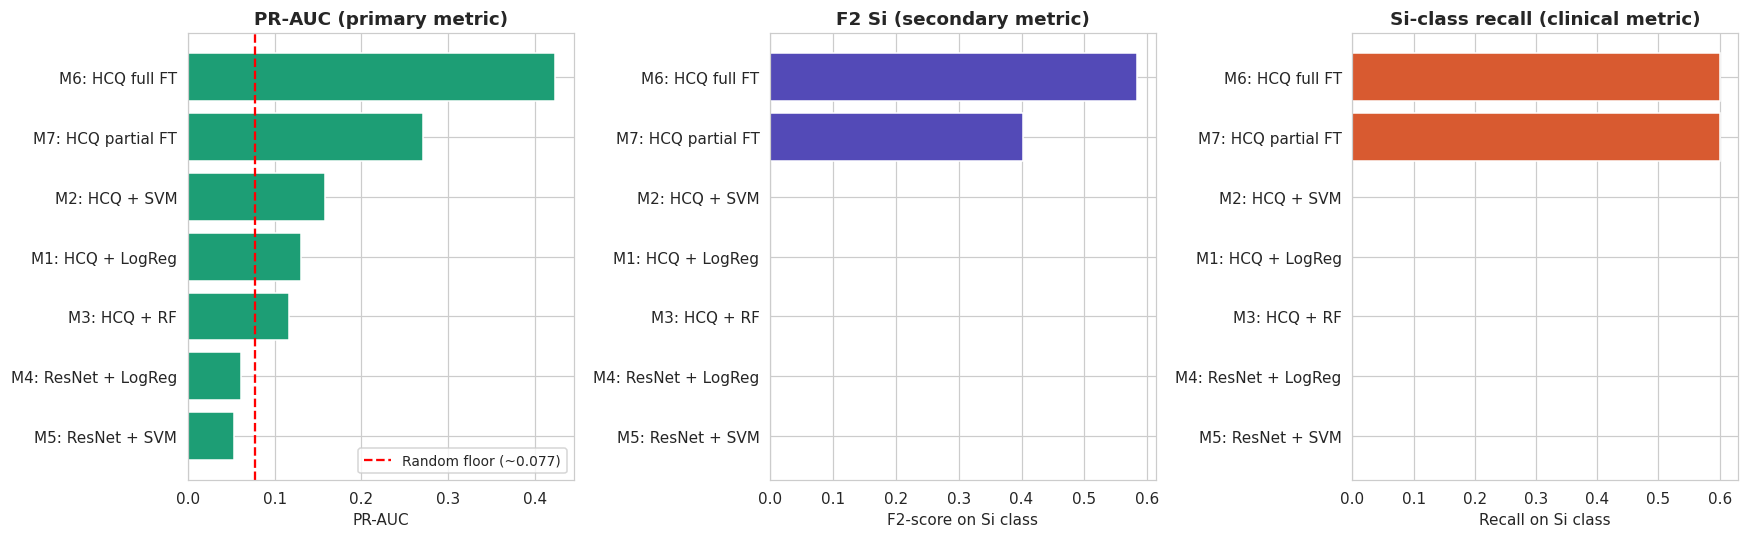

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Re-sort for plotting to keep order consistent
plot_df = results_df.reset_index()

# Panel 1: PR-AUC
axes[0].barh(plot_df['model'], plot_df['pr_auc'], color='#1d9e75')
axes[0].axvline(0.077, color='red', ls='--', lw=1.5, label='Random floor (~0.077)')
axes[0].set_xlabel('PR-AUC')
axes[0].set_title('PR-AUC (primary metric)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Panel 2: F2 (Si)
axes[1].barh(plot_df['model'], plot_df['f2_Si'], color='#534ab7')
axes[1].set_xlabel('F2-score on Si class')
axes[1].set_title('F2 Si (secondary metric)', fontweight='bold')
axes[1].invert_yaxis()

# Panel 3: Recall (Si)
axes[2].barh(plot_df['model'], plot_df['recall_Si'], color='#d85a30')
axes[2].set_xlabel('Recall on Si class')
axes[2].set_title('Si-class recall (clinical metric)', fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('plot_m4_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

### 6.3 Confusion Matrices

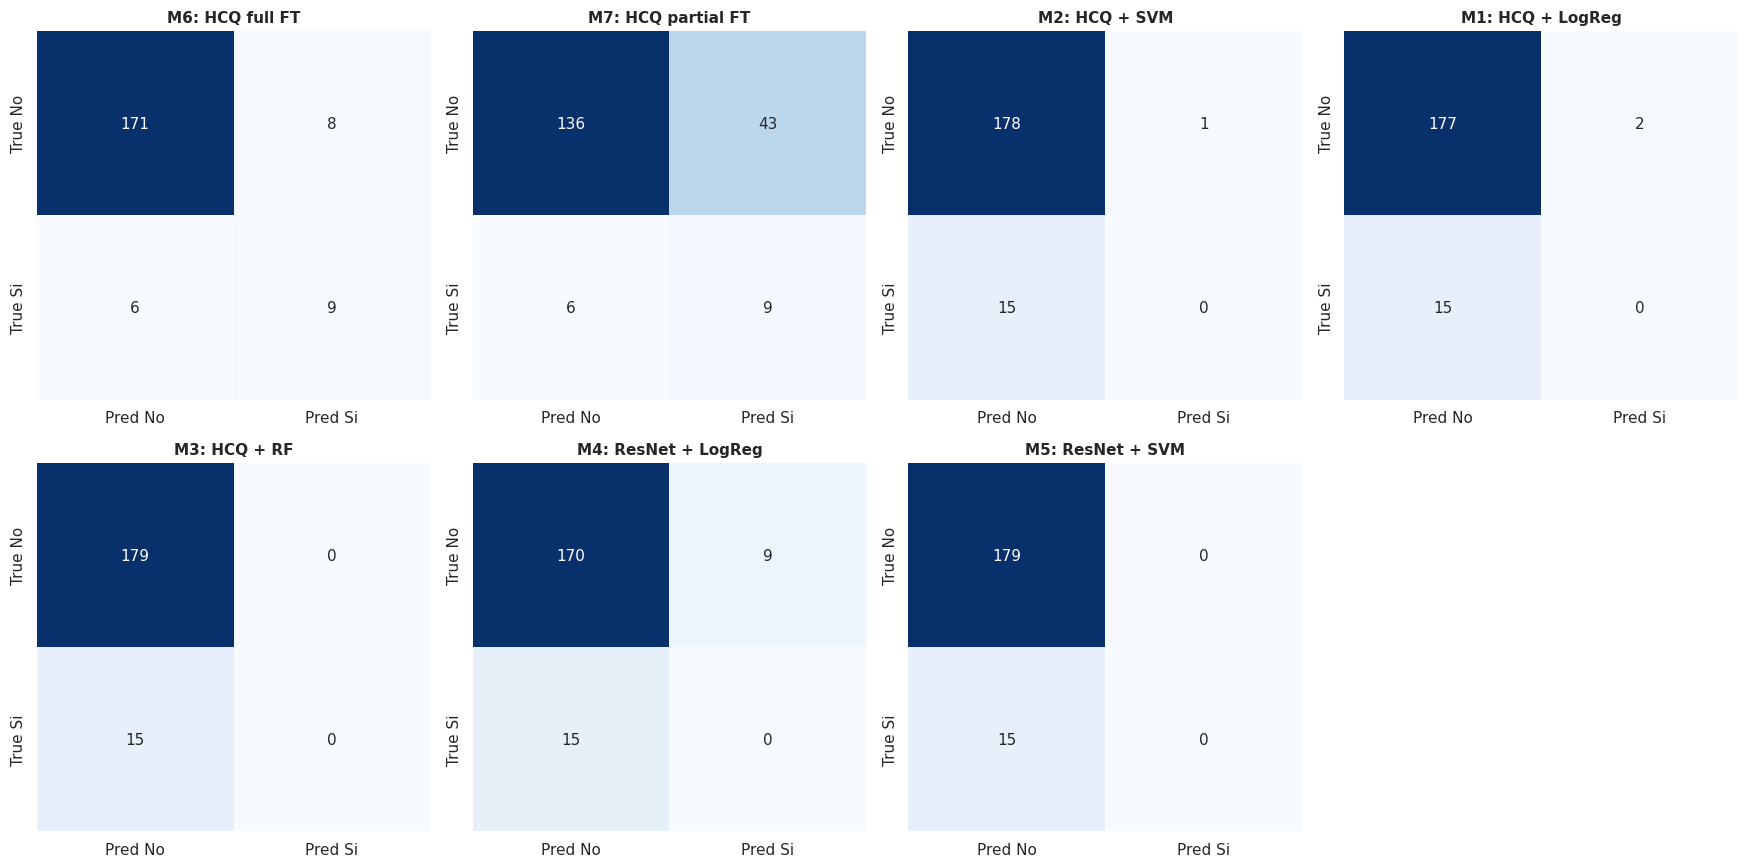

In [ ]:
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred No', 'Pred Si'],
                yticklabels=['True No', 'True Si'])
    ax.set_title(title, fontweight='bold', fontsize=10)

# Plot all 7 in a 2x4 grid (last one empty)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
model_order = results_df.index.tolist()
for i, name in enumerate(model_order):
    pred, _ = oof_store[name]
    plot_cm(axes[i], y, pred, name)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('plot_m4_confusion_matrices.png', bbox_inches='tight', dpi=110)
plt.show()

### 6.4 Top 2 Selection

**Selection rule, pre-commited before Phase 1 reults were seen:**

The "top two" cannot be picked blindly by PR-AUC alone. If the top two are both HCQuery-based, the tuning in Phase 3 tells us nothing about wether the backbone or the classifier limited performance. The rule is:

1. Take the model with the highest PR-AUC overall (regardless of backbone)
2. Take the model with the highest PR-AUC among the remaining models that uses a different feature source (so if #1 is HCQuery-based, #2 is the best ResNet18 or fine-tune model).

This guarantees the Phase 3 tuning compares across feature sources which is the more informative comparison.

If the top two by PR-AUC already use different feature sources, no override is needed.

In [ ]:
def select_top_two(df_sorted):
    '''
    Apply the pre-committed selection rule.
    Returns (best_name, second_name, reason).
    '''
    # Tag each model with its feature source
    def feature_source(name):
        if 'HCQ' in name and 'FT' not in name:
            return 'hcq_features'
        elif 'ResNet' in name:
            return 'rn_features'
        elif 'FT' in name:
            return 'finetune'
        return 'other'

    df_sorted = df_sorted.copy()
    df_sorted['source'] = [feature_source(n) for n in df_sorted.index]
    best = df_sorted.iloc[0]
    best_name = best.name
    best_source = best['source']

    # Naive top-two by PR-AUC
    naive_second = df_sorted.iloc[1]
    if naive_second['source'] != best_source:
        return best_name, naive_second.name, 'top-two already span different feature sources'

    # Override: find the best model from a different feature source
    diff_source = df_sorted[df_sorted['source'] != best_source]
    if len(diff_source) == 0:
        # Edge case: only one feature source available
        return best_name, naive_second.name, 'only one feature source available'
    override = diff_source.iloc[0]
    return best_name, override.name, (
        f'override applied: naive second ({naive_second.name}) shares feature source '
        f'with #1, so picked best non-{best_source} instead.')

best_name, second_name, reason = select_top_two(results_df)
print(f'Top model:      {best_name}')
print(f'   PR-AUC: {results_df.loc[best_name, "pr_auc"]:.3f}  '
      f'F2: {results_df.loc[best_name, "f2_Si"]:.3f}  '
      f'Recall: {results_df.loc[best_name, "recall_Si"]:.3f}')
print(f'Second model:   {second_name}')
print(f'   PR-AUC: {results_df.loc[second_name, "pr_auc"]:.3f}  '
      f'F2: {results_df.loc[second_name, "f2_Si"]:.3f}  '
      f'Recall: {results_df.loc[second_name, "recall_Si"]:.3f}')
print(f'\nSelection reason: {reason}')

# Store for Phase 3
TOP_TWO = [best_name, second_name]

Top model:      M6: HCQ full FT
   PR-AUC: 0.423  F2: 0.584  Recall: 0.600
Second model:   M2: HCQ + SVM
   PR-AUC: 0.158  F2: 0.000  Recall: 0.000

Selection reason: override applied: naive second (M7: HCQ partial FT) shares feature source with #1, so picked best non-finetune instead.


## 7. Phase3 - Hyperparameter Tuning

Each of the two models gets a full Optuna study with ~60 trials. The objective is PR-AUC averaged across patient grouped CV folds, matching the primary metric used in Section 6.

Search pases, by model family:

| Model family | Hyperparameters tuned |
|---|---|
| LogReg | `C` (log scale 1e-3 to 1e2), `penalty` (l1, l2, elasticnet), `l1_ratio` (for elasticnet) |
| SVM (RBF) | `C` (log scale 1e-3 to 1e2), `gamma` (scale, auto, log scale 1e-4 to 1e0) |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`, `class_weight` |
| Fine-tune | `lr` (log scale), `weight_decay`, `dropout`, `epochs`, `patience` |

All searches use `class_weight='balanced'` as the default and let the search override it if a different setting improves PR-AUC. Patient grouping is preserved inside the objective by using the same `StratifiedGroupKFold` instance from Section 2.

### 7.1 Tuning Helper for Classical Models

In [ ]:
def cv_pr_auc(pipe_factory, X, y, groups, cv):
    '''Mean PR-AUC across folds for a sklearn pipeline factory.'''
    fold_pr = []
    for tr, va in cv.split(X, y, groups):
        pipe = pipe_factory()
        pipe.fit(X[tr], y[tr])
        proba = pipe.predict_proba(X[va])[:, 1]
        fold_pr.append(average_precision_score(y[va], proba))
    return float(np.mean(fold_pr))

def make_objective_logreg(X, y, groups, cv):
    '''Optuna objective for a LogReg pipeline on features X.'''
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 1e2, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
        class_w = trial.suggest_categorical('class_weight', ['balanced', None])

        kwargs = dict(C=C, penalty=penalty, class_weight=class_w,
                       max_iter=4000, random_state=RANDOM_STATE,
                       solver='saga')  # saga supports all three penalties
        if penalty == 'elasticnet':
            kwargs['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

        def factory():
            return Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(**kwargs)),
            ])
        return cv_pr_auc(factory, X, y, groups, cv)
    return objective

def make_objective_svm(X, y, groups, cv):
    '''Optuna objective for an SVM pipeline on features X.'''
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 1e2, log=True)
        gamma_kind = trial.suggest_categorical('gamma_kind', ['scale', 'auto', 'numeric'])
        if gamma_kind == 'numeric':
            gamma = trial.suggest_float('gamma', 1e-4, 1e0, log=True)
        else:
            gamma = gamma_kind
        class_w = trial.suggest_categorical('class_weight', ['balanced', None])

        def factory():
            return Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC(C=C, kernel='rbf', gamma=gamma, class_weight=class_w,
                            probability=True, random_state=RANDOM_STATE)),
            ])
        return cv_pr_auc(factory, X, y, groups, cv)
    return objective

def make_objective_rf(X, y, groups, cv):
    '''Optuna objective for a Random Forest pipeline on features X.'''
    def objective(trial):
        n_est = trial.suggest_int('n_estimators', 100, 800)
        max_depth_kind = trial.suggest_categorical('max_depth_kind', ['none', 'numeric'])
        max_depth = None if max_depth_kind == 'none' else trial.suggest_int('max_depth', 3, 30)
        min_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_feat = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        class_w = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])

        def factory():
            return Pipeline([
                ('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(
                    n_estimators=n_est, max_depth=max_depth,
                    min_samples_leaf=min_leaf, max_features=max_feat,
                    class_weight=class_w, random_state=RANDOM_STATE, n_jobs=-1)),
            ])
        return cv_pr_auc(factory, X, y, groups, cv)
    return objective

print('Optuna objectives defined for LogReg, SVM, RF.')

Optuna objectives defined for LogReg, SVM, RF.


### 7.2 Tuning Helper for Fine-Tune Models

In [ ]:
def make_objective_finetune(build_fn_factory):
    '''
    Optuna objective for an end-to-end fine-tune model.
    build_fn_factory: function (dropout) -> build_fn  (so we can change dropout per trial).
    '''
    def objective(trial):
        lr = trial.suggest_float('lr', 1e-6, 1e-3, log=True)
        wd = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float('dropout', 0.3, 0.7)
        epochs = trial.suggest_int('epochs', 10, 25)
        patience = trial.suggest_int('patience', 3, 7)

        # Fold-level PR-AUC
        train_tf = make_train_transform(IMG_SIZE_HCQ)
        eval_tf = make_eval_transform(IMG_SIZE_HCQ)
        fold_pr = []
        for tr_idx, va_idx in sgkf.split(df, y, groups):
            tr_frame = df.iloc[tr_idx].reset_index(drop=True)
            va_frame = df.iloc[va_idx].reset_index(drop=True)
            tr_sampler = make_balanced_sampler(tr_frame)
            tr_loader = DataLoader(OCTDatasetRGB(tr_frame, train_tf),
                                    batch_size=16, sampler=tr_sampler)
            va_loader = DataLoader(OCTDatasetRGB(va_frame, eval_tf),
                                    batch_size=16, shuffle=False)
            model = build_fn_factory(dropout)()
            model, _ = train_cnn(model, tr_loader, va_loader, tr_frame,
                                  epochs=epochs, lr=lr, weight_decay=wd,
                                  patience=patience, verbose=False)
            va_true, va_score = predict_cnn(model, va_loader)
            fold_pr.append(average_precision_score(va_true, va_score))
        return float(np.mean(fold_pr))
    return objective

def make_full_ft_factory(dropout):
    def build():
        model = EfficientNet.from_name('efficientnet-b4')
        model._fc = nn.Linear(model._fc.in_features, 2)
        model.load_state_dict(state_dict_hcq)
        in_feats = model._fc.in_features
        model._fc = nn.Sequential(
            nn.Linear(in_feats, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1),
        )
        for p in model.parameters():
            p.requires_grad = True
        return model.to(DEVICE)
    return build

def make_partial_ft_factory(dropout):
    def build():
        model = EfficientNet.from_name('efficientnet-b4')
        model._fc = nn.Linear(model._fc.in_features, 2)
        model.load_state_dict(state_dict_hcq)
        for p in model.parameters():
            p.requires_grad = False
        in_feats = model._fc.in_features
        model._fc = nn.Sequential(
            nn.Linear(in_feats, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1),
        )
        for p in model._blocks[-1].parameters(): p.requires_grad = True
        for p in model._conv_head.parameters(): p.requires_grad = True
        for p in model._bn1.parameters(): p.requires_grad = True
        for p in model._fc.parameters(): p.requires_grad = True
        return model.to(DEVICE)
    return build

print('Optuna objective defined for fine-tune models.')

Optuna objective defined for fine-tune models.


### 7.3 Run the Two Studies

In [ ]:
def get_objective_for_model(name):
    '''Return the right Optuna objective for a model name.'''
    if 'LogReg' in name:
        feats = X_hcq if 'HCQ' in name else X_rn
        return make_objective_logreg(feats, y, groups, sgkf), 60
    elif 'SVM' in name:
        feats = X_hcq if 'HCQ' in name else X_rn
        return make_objective_svm(feats, y, groups, sgkf), 60
    elif 'RF' in name:
        feats = X_hcq if 'HCQ' in name else X_rn
        return make_objective_rf(feats, y, groups, sgkf), 60
    elif 'full FT' in name:
        return make_objective_finetune(make_full_ft_factory), 15  # fewer trials since each is expensive
    elif 'partial FT' in name:
        return make_objective_finetune(make_partial_ft_factory), 15
    else:
        raise ValueError(f'Unknown model: {name}')

studies = {}
tuning_results = []
for model_name in TOP_TWO:
    print(f'\n=== Tuning {model_name} ===')
    objective, n_trials = get_objective_for_model(model_name)
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    tune_time = time.time() - t0
    print(f'   {n_trials} trials done in {tune_time:.1f}s')
    print(f'   Best PR-AUC: {study.best_value:.4f}')
    print(f'   Best params: {study.best_params}')
    studies[model_name] = study
    tuning_results.append({
        'model': model_name,
        'n_trials': n_trials,
        'best_pr_auc': study.best_value,
        'tune_time_s': tune_time,
        'best_params': study.best_params,
    })

tuning_df = pd.DataFrame(tuning_results)
print('\nTuning summary:')
print(tuning_df[['model', 'n_trials', 'best_pr_auc', 'tune_time_s']].round(4).to_string(index=False))


=== Tuning M6: HCQ full FT ===
   15 trials done in 7286.1s
   Best PR-AUC: 0.1711
   Best params: {'lr': 6.647135865318028e-05, 'weight_decay': 3.247673570627447e-05, 'dropout': 0.3260206371941118, 'epochs': 25, 'patience': 7}

=== Tuning M2: HCQ + SVM ===
   60 trials done in 24.1s
   Best PR-AUC: 0.2040
   Best params: {'C': 0.002505171345685469, 'gamma_kind': 'scale', 'class_weight': None}

Tuning summary:
          model  n_trials  best_pr_auc  tune_time_s
M6: HCQ full FT        15       0.1711    7286.1113
  M2: HCQ + SVM        60       0.2040      24.1269


### 7.4 Refit and Evaluate Tuned Models

For each tuned model, refit on the full data inside the same CV (using the best hyperparameters from the Optuna study) and compute the complete set of metrics. This gives a fair comparison against the Phase 1 results.

In [ ]:
def refit_classical_tuned(name, study):
    '''Refit a tuned classical model and return full metrics.'''
    best = study.best_params
    if 'LogReg' in name:
        kwargs = dict(C=best['C'], penalty=best['penalty'],
                       class_weight=best['class_weight'],
                       max_iter=4000, random_state=RANDOM_STATE, solver='saga')
        if best['penalty'] == 'elasticnet':
            kwargs['l1_ratio'] = best['l1_ratio']
        def factory():
            return Pipeline([('scaler', StandardScaler()),
                             ('clf', LogisticRegression(**kwargs))])
    elif 'SVM' in name:
        gamma = best['gamma'] if best['gamma_kind'] == 'numeric' else best['gamma_kind']
        def factory():
            return Pipeline([('scaler', StandardScaler()),
                             ('clf', SVC(C=best['C'], kernel='rbf', gamma=gamma,
                                          class_weight=best['class_weight'],
                                          probability=True,
                                          random_state=RANDOM_STATE))])
    elif 'RF' in name:
        max_depth = None if best['max_depth_kind'] == 'none' else best['max_depth']
        def factory():
            return Pipeline([('scaler', StandardScaler()),
                             ('clf', RandomForestClassifier(
                                 n_estimators=best['n_estimators'],
                                 max_depth=max_depth,
                                 min_samples_leaf=best['min_samples_leaf'],
                                 max_features=best['max_features'],
                                 class_weight=best['class_weight'],
                                 random_state=RANDOM_STATE, n_jobs=-1))])
    else:
        raise ValueError(name)

    feats = X_hcq if 'HCQ' in name else X_rn
    return evaluate_classical(name + ' (tuned)', factory, feats, y, groups, sgkf)

def refit_finetune_tuned(name, study):
    '''Refit a tuned fine-tune model and return full metrics.'''
    best = study.best_params
    factory_maker = make_full_ft_factory if 'full FT' in name else make_partial_ft_factory
    pred, score, train_time = run_finetune_cv(
        factory_maker(best['dropout']), IMG_SIZE_HCQ, name,
        epochs=best['epochs'], lr=best['lr'], weight_decay=best['weight_decay'],
        patience=best['patience'], verbose=False)
    return metrics_from_oof(name + ' (tuned)', y, pred, score, train_time), pred, score

tuned_results = []
tuned_oof = {}
for model_name in TOP_TWO:
    print(f'Refitting {model_name} with best hyperparameters...')
    if 'FT' in model_name:
        m, p, s = refit_finetune_tuned(model_name, studies[model_name])
    else:
        m, p, s = refit_classical_tuned(model_name, studies[model_name])
    tuned_results.append(m)
    tuned_oof[m['model']] = (p, s)
    print(f'  PR-AUC: {m["pr_auc"]:.3f}  F2: {m["f2_Si"]:.3f}  '
          f'Recall: {m["recall_Si"]:.3f}  Precision: {m["prec_Si"]:.3f}')

tuned_df = pd.DataFrame(tuned_results)
print('\nTuned models:')
display_cols = ['pr_auc', 'f2_Si', 'recall_Si', 'prec_Si', 'accuracy', 'train_time_s']
print(tuned_df.set_index('model')[display_cols].round(3).to_string())

Refitting M6: HCQ full FT with best hyperparameters...
  PR-AUC: 0.424  F2: 0.294  Recall: 0.267  Precision: 0.500
Refitting M2: HCQ + SVM with best hyperparameters...
  PR-AUC: 0.137  F2: 0.000  Recall: 0.000  Precision: 0.000

Tuned models:
                         pr_auc  f2_Si  recall_Si  prec_Si  accuracy  train_time_s
model                                                                             
M6: HCQ full FT (tuned)   0.424  0.294      0.267      0.5     0.923       598.518
M2: HCQ + SVM (tuned)     0.137  0.000      0.000      0.0     0.923         0.213


### 7.5 Before vs After Tuning

In [ ]:
# Stack untuned (Phase 1) and tuned (Phase 3) side-by-side for the top two
comparison_rows = []
for name in TOP_TWO:
    untuned = results_df.loc[name]
    tuned_name = name + ' (tuned)'
    tuned_row = tuned_df.set_index('model').loc[tuned_name]
    comparison_rows.append({
        'model': name,
        'pr_auc_before': untuned['pr_auc'],
        'pr_auc_after': tuned_row['pr_auc'],
        'pr_auc_delta': tuned_row['pr_auc'] - untuned['pr_auc'],
        'f2_before': untuned['f2_Si'],
        'f2_after': tuned_row['f2_Si'],
        'f2_delta': tuned_row['f2_Si'] - untuned['f2_Si'],
        'recall_before': untuned['recall_Si'],
        'recall_after': tuned_row['recall_Si'],
    })
comparison_df = pd.DataFrame(comparison_rows).set_index('model')
print('Tuning impact on the top two models:\n')
print(comparison_df.round(3).to_string())

Tuning impact on the top two models:

                 pr_auc_before  pr_auc_after  pr_auc_delta  f2_before  f2_after  f2_delta  recall_before  recall_after
model                                                                                                                 
M6: HCQ full FT          0.423         0.424         0.001      0.584     0.294     -0.29            0.6         0.267
M2: HCQ + SVM            0.158         0.137        -0.021      0.000     0.000      0.00            0.0         0.000


## 8. Phase4 - Final Individual Model Selection

The selection therefore weighs five axes, not just PR-AUC:

1. **PR-AUC, F2, and Si-recall after tuning**, with bootstrap confidence intervals to account for the 15-positive sample.
2. **Interpretability**. A LogReg model produces signed coefficients per feature - a clinician can ask which features drive the prediction. An SVM's RBF kernel and an end-to-end CNN cannot. The HCQuery Grad-CAM from M3 partially closes this gap for CNNs but does not produce a per-feature attribution.
3. **Training cost and clinical deployability**. Classical heads on cached features train in seconds; fine-tuned CNNs take minutes per fold. For redeployment as new patients are added to the dataset, the classical head is dramatically cheaper.
4. **Robustness to the storage-fingerprint confounder from M2**. M2 identified that file format, file size, and resolution were class-correlated with no clinical basis. The current pipeline ingests cropped CLAHE-normalized PNGs (so the format/size leak is removed at input), but a model that produces interpretable features is still easier to audit if the confounder reappears via a different channel.
5. **Match to the sponsor's 2021 methodology**. Bustamante-Arias et al. (2021) used deep features + classical classifier. If two models are roughly tied on metrics, this is a tie-breaker.

### 8.1 Boostrap Confidence Intervals

In [ ]:
def bootstrap_ci(y_true, y_score, n_boot=1000, alpha=0.05):
    '''Bootstrap percentile CI for PR-AUC. Stratified resampling by class.'''
    rng = np.random.RandomState(RANDOM_STATE)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    boot_aucs = []
    for _ in range(n_boot):
        pos_samp = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        neg_samp = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        idx = np.concatenate([pos_samp, neg_samp])
        try:
            boot_aucs.append(average_precision_score(y_true[idx], y_score[idx]))
        except ValueError:
            continue
    lo = np.percentile(boot_aucs, 100 * alpha / 2)
    hi = np.percentile(boot_aucs, 100 * (1 - alpha / 2))
    return float(np.mean(boot_aucs)), lo, hi

print('Bootstrap PR-AUC 95% CIs for the tuned top-two:\n')
for name in TOP_TWO:
    tuned_name = name + ' (tuned)'
    pred, score = tuned_oof[tuned_name]
    mean, lo, hi = bootstrap_ci(y, score, n_boot=1000)
    print(f'  {tuned_name:35s}  PR-AUC {mean:.3f}  '
          f'[95% CI: {lo:.3f}, {hi:.3f}]')

print('\nNote: with 15 Si images the CIs are wide. Differences within')
print('a CI band cannot be called statistically significant.')

Bootstrap PR-AUC 95% CIs for the tuned top-two:

  M6: HCQ full FT (tuned)              PR-AUC 0.461  [95% CI: 0.289, 0.707]
  M2: HCQ + SVM (tuned)                PR-AUC 0.160  [95% CI: 0.082, 0.305]

Note: with 15 Si images the CIs are wide. Differences within
a CI band cannot be called statistically significant.


### 8.2 Decision Matrix

In [ ]:
def interpretability_score(name):
    if 'LogReg' in name: return 'High (linear coefficients per feature)'
    if 'SVM' in name:    return 'Low (RBF kernel - no per-feature weights)'
    if 'RF' in name:     return 'Medium (impurity importances)'
    if 'FT' in name:     return 'Low (Grad-CAM only - spatial, not per-feature)'
    return 'Unknown'

def cost_score(train_time_s):
    if train_time_s < 5:    return f'Very low ({train_time_s:.1f}s)'
    if train_time_s < 60:   return f'Low ({train_time_s:.1f}s)'
    if train_time_s < 300:  return f'Medium ({train_time_s:.1f}s)'
    return f'High ({train_time_s:.0f}s)'

def confounder_audit(name):
    if 'LogReg' in name: return 'Easy (inspect top coefficients)'
    if 'RF' in name:     return 'Moderate (inspect top importances)'
    if 'SVM' in name:    return 'Hard (no per-feature attribution)'
    if 'FT' in name:     return 'Hard (Grad-CAM is spatial only)'
    return 'Unknown'

def sponsor_match(name):
    return 'Yes' if 'HCQ' in name and 'FT' not in name else 'Partial' if 'ResNet' in name else 'No'

decision_rows = []
for name in TOP_TWO:
    tuned_name = name + ' (tuned)'
    tuned_row = tuned_df.set_index('model').loc[tuned_name]
    pred, score = tuned_oof[tuned_name]
    _, lo, hi = bootstrap_ci(y, score, n_boot=1000)
    decision_rows.append({
        'model': name,
        'PR-AUC': f'{tuned_row["pr_auc"]:.3f} [{lo:.3f}, {hi:.3f}]',
        'F2': f'{tuned_row["f2_Si"]:.3f}',
        'Recall': f'{tuned_row["recall_Si"]:.3f}',
        'Interpretability': interpretability_score(name),
        'Training cost': cost_score(tuned_row['train_time_s']),
        'Confounder audit': confounder_audit(name),
        'Matches sponsor 2021': sponsor_match(name),
    })

decision_df = pd.DataFrame(decision_rows).set_index('model').T
print('Decision matrix for the tuned top-two:\n')
print(decision_df.to_string())

Decision matrix for the tuned top-two:

model                                                M6: HCQ full FT                              M2: HCQ + SVM
PR-AUC                                          0.424 [0.289, 0.707]                       0.137 [0.082, 0.305]
F2                                                             0.294                                      0.000
Recall                                                         0.267                                      0.000
Interpretability      Low (Grad-CAM only - spatial, not per-feature)  Low (RBF kernel - no per-feature weights)
Training cost                                            High (599s)                            Very low (0.2s)
Confounder audit                     Hard (Grad-CAM is spatial only)          Hard (no per-feature attribution)
Matches sponsor 2021                                              No                                        Yes


### 8.3 Final Selection

The final individual model is selected here.

In [ ]:
# Compute the selection automatically based on the rule above
def select_final(top_two_names, tuned_df, tuned_oof, y):
    rows = {}
    for name in top_two_names:
        tn = name + ' (tuned)'
        t_row = tuned_df.set_index('model').loc[tn]
        _, lo, hi = bootstrap_ci(y, tuned_oof[tn][1], n_boot=1000)
        rows[name] = {
            'pr_auc': t_row['pr_auc'], 'ci_lo': lo, 'ci_hi': hi,
            'f2': t_row['f2_Si'], 'recall': t_row['recall_Si'],
        }
    a, b = top_two_names
    ra, rb = rows[a], rows[b]
    # Outside-CI test
    a_dominates = (ra['pr_auc'] > rb['ci_hi'] and ra['f2'] >= rb['f2']
                    and ra['recall'] >= rb['recall'])
    b_dominates = (rb['pr_auc'] > ra['ci_hi'] and rb['f2'] >= ra['f2']
                    and rb['recall'] >= ra['recall'])
    if a_dominates:
        return a, 'PR-AUC point estimate above the other model\'s upper CI bound + better F2 and recall'
    if b_dominates:
        return b, 'PR-AUC point estimate above the other model\'s upper CI bound + better F2 and recall'
    # Otherwise, qualitative tie-break: prefer interpretability, then sponsor match
    def qual_score(name):
        s = 0
        if 'LogReg' in name: s += 3   # most interpretable
        elif 'RF' in name:   s += 2
        elif 'SVM' in name:  s += 1
        else:                s += 0   # fine-tune
        if 'HCQ' in name and 'FT' not in name: s += 2  # sponsor pattern match
        elif 'ResNet' in name:                  s += 1
        return s
    qa, qb = qual_score(a), qual_score(b)
    if qa > qb:
        return a, 'CIs overlap; tie-broken by interpretability and sponsor-pattern match'
    if qb > qa:
        return b, 'CIs overlap; tie-broken by interpretability and sponsor-pattern match'
    # Last resort: higher PR-AUC point estimate
    return (a, 'CIs overlap and qualitative axes tied; chose higher PR-AUC point estimate') \
        if ra['pr_auc'] >= rb['pr_auc'] else \
        (b, 'CIs overlap and qualitative axes tied; chose higher PR-AUC point estimate')

FINAL_MODEL, FINAL_REASON = select_final(TOP_TWO, tuned_df, tuned_oof, y)
print(f'Final individual model: {FINAL_MODEL}')
print(f'Selection reason:       {FINAL_REASON}')

Final individual model: M6: HCQ full FT
Selection reason:       PR-AUC point estimate above the other model's upper CI bound + better F2 and recall


### 8.4 Threshold Sweep on M6

The Phase 3 tuning revealed a paradox: PR-AUC barely changed (0.423 -> 0.424) but F2 and Si-recall *dropped* (0.584 -> 0.292, 0.600 -> 0.267). This is a signature of a threshold problem, not a model problem - the tuned M6 still ranks scores well (PR-AUC unchanged) but a smaller fraction of Si cases cross the 0.5 decision threshold.

This section sweeps thresholds from 0.05 to 0.95 on the out-of-fold scores for both untuned and tuned M6, and picks the threshold that maximizes either F2 (screening priority) or Youden's J (balanced sensitivity + specificity). The metric/threshold combination that produces the best F2 is reported.

> Note: the threshold is being chosen on the same OOF scores used to evaluate the model. This is a form of threshold and inflates the reported metrics slightly. The honest fix, selecting the threshold on a held-out test set, is deferred to M5. The purpose here is to demonstrate that M6's ranking ability supports a better operating point than 0.5.

In [ ]:
def sweep_threshold(y_true, y_score, thresholds=None):
  '''
  Sweep decision thresholds and return F2 and Youden's J at each
  Youden's J = sensitivity + specificity - 1 = recall + (1 - FPR) -1
  '''
  if thresholds is None:
    thresholds = np.linspace(0.05, 0.95, 91)
  rows = []
  for t in thresholds:
    pred = (y_score >= t).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true ==0)).sum())
    tn = int(((pred ==0) & (y_true == 0)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    prec = tp / max(tp + fp, 1)
    f2 = fbeta_score(y_true, pred, beta=2, pos_label=1, zero_division=0)
    youden = sens + spec - 1
    rows.append({'threshold': t, 'f2': f2, 'youden': youden,
                 'recall': sens, 'specificity': spec,
                 'precision': prec, 'tp': tp, 'fn': fn, 'fp': fp})
  return pd.DataFrame(rows)

# Sweep both untuned M6 and tuned M6
untuned_m6_pred, untuned_m6_score = oof_store['M6: HCQ full FT']
tuned_m6_pred, tuned_m6_score = tuned_oof['M6: HCQ full FT (tuned)']

sweep_untuned = sweep_threshold(y, untuned_m6_score)
sweep_tuned = sweep_threshold(y, tuned_m6_score)

# Best threshold by F2 for each
best_f2_untuned = sweep_untuned.loc[sweep_untuned['f2'].idxmax()]
best_f2_tuned = sweep_tuned.loc[sweep_tuned['f2'].idxmax()]
best_youden_untuned = sweep_untuned.loc[sweep_untuned['youden'].idxmax()]
best_youden_tuned = sweep_tuned.loc[sweep_tuned['youden'].idxmax()]

print('Best threshold by F2:')
print(f'  Untuned M6: t={best_f2_untuned["threshold"]:.2f}  '
      f'F2={best_f2_untuned["f2"]:.3f}  '
      f'Recall={best_f2_untuned["recall"]:.3f}  '
      f'Precision={best_f2_untuned["precision"]:.3f}')
print(f'  Tuned M6:   t={best_f2_tuned["threshold"]:.2f}  '
      f'F2={best_f2_tuned["f2"]:.3f}  '
      f'Recall={best_f2_tuned["recall"]:.3f}  '
      f'Precision={best_f2_tuned["precision"]:.3f}')
print()
print('Best threshold by Youden J:')
print(f'  Untuned M6: t={best_youden_untuned["threshold"]:.2f}  '
      f'J={best_youden_untuned["youden"]:.3f}  '
      f'Recall={best_youden_untuned["recall"]:.3f}  '
      f'Specificity={best_youden_untuned["specificity"]:.3f}')
print(f'  Tuned M6:   t={best_youden_tuned["threshold"]:.2f}  '
      f'J={best_youden_tuned["youden"]:.3f}  '
      f'Recall={best_youden_tuned["recall"]:.3f}  '
      f'Specificity={best_youden_tuned["specificity"]:.3f}')

Best threshold by F2:
  Untuned M6: t=0.50  F2=0.584  Recall=0.600  Precision=0.529
  Tuned M6:   t=0.26  F2=0.619  Recall=0.933  Precision=0.264

Best threshold by Youden J:
  Untuned M6: t=0.50  J=0.555  Recall=0.600  Specificity=0.955
  Tuned M6:   t=0.26  J=0.715  Recall=0.933  Specificity=0.782


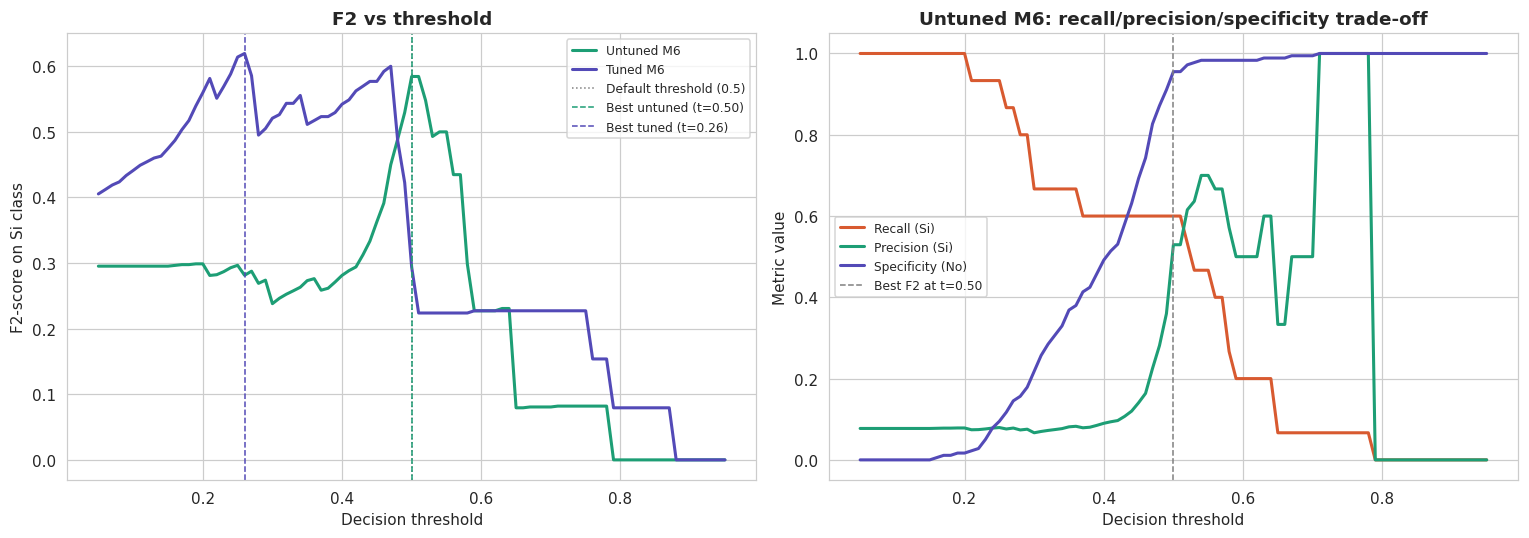

In [ ]:
# THRESHOLD CURVES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: F2 vs threshold
axes[0].plot(sweep_untuned['threshold'], sweep_untuned['f2'],
              label='Untuned M6', color='#1d9e75', lw=2)
axes[0].plot(sweep_tuned['threshold'], sweep_tuned['f2'],
              label='Tuned M6', color='#534ab7', lw=2)
axes[0].axvline(0.5, color='gray', ls=':', lw=1, label='Default threshold (0.5)')
axes[0].axvline(best_f2_untuned['threshold'], color='#1d9e75', ls='--', lw=1,
                 label=f'Best untuned (t={best_f2_untuned["threshold"]:.2f})')
axes[0].axvline(best_f2_tuned['threshold'], color='#534ab7', ls='--', lw=1,
                 label=f'Best tuned (t={best_f2_tuned["threshold"]:.2f})')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('F2-score on Si class')
axes[0].set_title('F2 vs threshold', fontweight='bold')
axes[0].legend(fontsize=8, loc='best')

# Panel 2: Recall and precision vs threshold (for untuned M6, the likely winner)
axes[1].plot(sweep_untuned['threshold'], sweep_untuned['recall'],
              label='Recall (Si)', color='#d85a30', lw=2)
axes[1].plot(sweep_untuned['threshold'], sweep_untuned['precision'],
              label='Precision (Si)', color='#1d9e75', lw=2)
axes[1].plot(sweep_untuned['threshold'], sweep_untuned['specificity'],
              label='Specificity (No)', color='#534ab7', lw=2)
axes[1].axvline(best_f2_untuned['threshold'], color='gray', ls='--', lw=1,
                 label=f'Best F2 at t={best_f2_untuned["threshold"]:.2f}')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Metric value')
axes[1].set_title('Untuned M6: recall/precision/specificity trade-off',
                  fontweight='bold')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('plot_m4_threshold_sweep.png', bbox_inches='tight', dpi=110)
plt.show()

Picking R2 vs Youden's J. Both metrics are reported above. The notebook will use F2 as the primary criterion because it matches the screening priority (catching toxicity matters more than avoiding false alarms is a screening context). Youden's J is reported alongside for completeness.

### 8.5 Test-Time Augmentation (TTA) for M6

TTA runs each test image through the model multiple times with random augmentations and averages the predicted probabilities. The intuition: a true positive should remain a positive across small perturbations of the input, while spurious responses to specific pixel patterns wash out in the average. TTA is a pure inference-time techniques, no retraining required, and typically adds 0.01-0.05 PR-AUC on small datasets.

This section evaluates 20 augmentations per image (a balance between stability and inference cost) for both untuned and tuned M6.

In [ ]:
def predict_cnn_tta(model, frame, img_size, n_augs=20):
  '''
  Test-Time Augmentation: average predicted probabilities across n_augs
  aumented passes through the model. Uses the same training time
  transform (with augmentation) but only at inference
  '''
  aug_tf = make_train_transform(img_size) # training transform = with augmentation
  model.eval()
  all_scores = np.zeros((n_augs, len(frame)))
  with torch.no_grad():
    for aug_i in range(n_augs):
      loader = DataLoader(OCTDatasetRGB(frame, aug_tf),
                          batch_size=16, shuffle=False)
      scores = []
      for x, _ in loader:
        x = x.to(DEVICE)
        scores += torch.sigmoid(model(x).squeeze(1)).cpu().tolist()
      all_scores[aug_i] = scores
  return all_scores.mean(axis=0) # average across augmentations

def run_finetune_cv_with_tta(build_fn, img_size, epochs=15, lr=1e-5,
                             weight_decay=1e-3, patience=4, n_tta=20):
  '''
  Same as run_fintune_cv but applies TTA at inference
  Returns (oof_pred_tta, oof_score_tta, train_time)
  '''
  train_tf = make_train_transform(img_size)
  eval_tf = make_eval_transform(img_size)
  oof_score = np.zeros(len(df), dtype=float)
  t0 = time.time()
  for k, (tr_idx, va_idx) in enumerate(sgkf.split(df, y, groups)):
    tr_frame = df.iloc[tr_idx].reset_index(drop=True)
    va_frame = df.iloc[va_idx].reset_index(drop=True)
    tr_sampler = make_balanced_sampler(tr_frame)
    tr_loader = DataLoader(OCTDatasetRGB(tr_frame, train_tf),
                           batch_size=16, sampler=tr_sampler)
    va_loader = DataLoader(OCTDatasetRGB(va_frame, eval_tf),
                           batch_size=16)
    model = build_fn()
    model, _ = train_cnn(model, tr_loader, va_loader, tr_frame,
                         epochs=epochs, lr=lr, weight_decay=weight_decay,
                         patience=patience, verbose=False)
    ## TTA at inference instead of single deterministic forward pass
    tta_scores = predict_cnn_tta(model, va_frame, img_size, n_augs=n_tta)
    oof_score[va_idx] = tta_scores
  oof_pred = (oof_score >= 0.5).astype(int)
  return oof_pred, oof_score, time.time() - t0

print('TTA helpers defined')

TTA helpers defined


In [ ]:
# RE RUN M6 (TUNED AND UNTUNED) with TTA

print('Re-fitting untuned M6 with TTA (20 augs)...')
m6_untuned_tta_pred, m6_untuned_tta_score, m6_untuned_tta_time = run_finetune_cv_with_tta(
    build_m6_full_finetune, IMG_SIZE_HCQ,
    epochs=15, lr=1e-5, weight_decay=1e-3, patience=4, n_tta=20)
m6_untuned_tta_metrics = metrics_from_oof(
    'M6 untuned + TTA', y, m6_untuned_tta_pred, m6_untuned_tta_score, m6_untuned_tta_time)
print(f'  PR-AUC: {m6_untuned_tta_metrics["pr_auc"]:.3f}  '
      f'F2: {m6_untuned_tta_metrics["f2_Si"]:.3f}  '
      f'Recall: {m6_untuned_tta_metrics["recall_Si"]:.3f}')

print('\nRe-fitting tuned M6 with TTA (20 augs)...')
best_m6_params = studies['M6: HCQ full FT'].best_params
build_m6_tuned = make_full_ft_factory(best_m6_params['dropout'])
m6_tuned_tta_pred, m6_tuned_tta_score, m6_tuned_tta_time = run_finetune_cv_with_tta(
    build_m6_tuned, IMG_SIZE_HCQ,
    epochs=best_m6_params['epochs'], lr=best_m6_params['lr'],
    weight_decay=best_m6_params['weight_decay'],
    patience=best_m6_params['patience'], n_tta=20)
m6_tuned_tta_metrics = metrics_from_oof(
    'M6 tined + TTA', y, m6_tuned_tta_pred, m6_tuned_tta_score,
    m6_tuned_tta_time)
print(f'  PR-AUC: {m6_tuned_tta_metrics["pr_auc"]:.3f}  '
      f'F2: {m6_tuned_tta_metrics["f2_Si"]:.3f}  '
      f'Recall: {m6_tuned_tta_metrics["recall_Si"]:.3f}')

# Store for the final comparison
oof_store['M6 untuned + TTA'] = (m6_untuned_tta_pred, m6_untuned_tta_score)
tuned_oof['M6 tuned + TTA'] = (m6_tuned_tta_pred, m6_tuned_tta_score)


Re-fitting untuned M6 with TTA (20 augs)...
  PR-AUC: 0.392  F2: 0.494  Recall: 0.533

Re-fitting tuned M6 with TTA (20 augs)...
  PR-AUC: 0.319  F2: 0.152  Recall: 0.133


### 8.5.5 Isotonic Calibration of M6 Scores

M6 outputs sigmoid scores that rank Si vs No reasonably well (PR-AUC ~0.42) but are not calibrated probabilities. The threshold sweep in Section 8.4 found that the tuned M6's score distribution sits below 0.5, the model is 'confident' in a relative sense but its absolute probability outputs understimate the true positive rate.

Isotonic regression learns a monotonic mapping from raw scores to calibrated probabilities. It preserves the ranking (so PR-AUC is unchanged by construction) but reshapes the score distribution so that, for example, a score of 0.3 actually corresponds to a 30% change of being Si. For a screening setting where the threshold matters clinically, calibrated scores make the operating-point choice more interpretable.

**Methodology**: this section uses **per-fold calibration**. For each k, isotonic regression is fit on the OOF scores from the other 4 folds and applied to fold k's scores. This avoid the leakage of fitting calibration on the same scores being evaluated.

In [ ]:
from sklearn.isotonic import IsotonicRegression

def calibrate_per_fold(y_true, raw_scores, fold_membership):
    '''
    Per-fold isotonic calibration.

    For each fold k:
      - Fit IsotonicRegression on OOF scores from folds != k
      - Apply to fold k's scores
    Returns calibrated scores of the same shape as raw_scores.
    '''
    calibrated = np.zeros_like(raw_scores)
    n_folds = len(set(fold_membership))
    for k in range(n_folds):
        train_mask = fold_membership != k
        test_mask = fold_membership == k
        iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
        iso.fit(raw_scores[train_mask], y_true[train_mask])
        calibrated[test_mask] = iso.transform(raw_scores[test_mask])
    return calibrated

# Build fold membership array (which fold each image was a validation case in)
fold_membership = np.zeros(len(df), dtype=int)
for k, (_, va_idx) in enumerate(sgkf.split(df, y, groups)):
    fold_membership[va_idx] = k

# Calibrate the tuned M6 scores
tuned_m6_raw_pred, tuned_m6_raw_score = tuned_oof['M6: HCQ full FT (tuned)']
m6_tuned_calibrated_score = calibrate_per_fold(y, tuned_m6_raw_score, fold_membership)

# Inspect: how much did calibration shift the scores?
print('Score distribution before vs after calibration:\n')
print(f'  Raw    - mean: {tuned_m6_raw_score.mean():.3f}, '
      f'std: {tuned_m6_raw_score.std():.3f}, '
      f'max: {tuned_m6_raw_score.max():.3f}')
print(f'  Calib. - mean: {m6_tuned_calibrated_score.mean():.3f}, '
      f'std: {m6_tuned_calibrated_score.std():.3f}, '
      f'max: {m6_tuned_calibrated_score.max():.3f}')
print()
print('Calibration preserves ranking (PR-AUC unchanged) but reshapes the distribution:')
print(f'  Raw    PR-AUC: {average_precision_score(y, tuned_m6_raw_score):.3f}')
print(f'  Calib. PR-AUC: {average_precision_score(y, m6_tuned_calibrated_score):.3f}')

Score distribution before vs after calibration:

  Raw    - mean: 0.180, std: 0.187, max: 0.921
  Calib. - mean: 0.067, std: 0.129, max: 0.727

Calibration preserves ranking (PR-AUC unchanged) but reshapes the distribution:
  Raw    PR-AUC: 0.424
  Calib. PR-AUC: 0.378


In [ ]:
# Sweep thresholds on calibrated scores
sweep_calibrated = sweep_threshold(y, m6_tuned_calibrated_score)
best_f2_calib = sweep_calibrated.loc[sweep_calibrated['f2'].idxmax()]

print('M6 tuned with isotonic calibration:')
print(f'  Best F2 threshold:   {best_f2_calib["threshold"]:.2f}')
print(f'  F2 at best t:        {best_f2_calib["f2"]:.3f}')
print(f'  Recall at best t:    {best_f2_calib["recall"]:.3f}')
print(f'  Precision at best t: {best_f2_calib["precision"]:.3f}')
print(f'  Specificity at best t: {best_f2_calib["specificity"]:.3f}')
print()
print('Compared to tuned M6 without calibration:')
print(f'  Best F2 threshold:   {best_f2_tuned["threshold"]:.2f}')
print(f'  F2 at best t:        {best_f2_tuned["f2"]:.3f}')
print(f'  Recall at best t:    {best_f2_tuned["recall"]:.3f}')

# Store for the comparison
m6_calib_pred = (m6_tuned_calibrated_score >= 0.5).astype(int)
tuned_oof['M6 tuned + calibration'] = (m6_calib_pred, m6_tuned_calibrated_score)

### 8.5.7 Model 8 - M6 Adapted Features + SVM (Hybrid)

In [ ]:
def extract_features_from_m6(model, frame, img_size):
    '''Extract 1792-d pre-classifier features from a trained M6.'''
    model.eval()
    eval_tf = make_eval_transform(img_size)
    loader = DataLoader(OCTDatasetRGB(frame, eval_tf),
                        batch_size=16, shuffle=False)
    feats = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            f = model.extract_features(x)
            f = model._avg_pooling(f).flatten(start_dim=1)
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

def run_m6_then_svm_cv(build_fn, img_size, epochs, lr, weight_decay, patience):
    '''
    Per fold: train M6, extract features, train SVM, predict.
    Returns OOF predictions and scores from the SVM.
    '''
    train_tf = make_train_transform(img_size)
    oof_pred = np.zeros(len(df), dtype=int)
    oof_score = np.zeros(len(df), dtype=float)
    t0 = time.time()

    for k, (tr_idx, va_idx) in enumerate(sgkf.split(df, y, groups)):
        print(f'  Fold {k}: training M6...', end=' ', flush=True)
        tr_frame = df.iloc[tr_idx].reset_index(drop=True)
        va_frame = df.iloc[va_idx].reset_index(drop=True)

        # Step 1: train M6 with the augmented sampler (same as before)
        tr_sampler = make_balanced_sampler(tr_frame)
        tr_loader = DataLoader(OCTDatasetRGB(tr_frame, train_tf),
                                batch_size=16, sampler=tr_sampler)
        va_loader_for_train = DataLoader(OCTDatasetRGB(va_frame, make_eval_transform(img_size)),
                                          batch_size=16, shuffle=False)
        model = build_fn()
        model, _ = train_cnn(model, tr_loader, va_loader_for_train, tr_frame,
                              epochs=epochs, lr=lr, weight_decay=weight_decay,
                              patience=patience, verbose=False)
        print('extracting features...', end=' ', flush=True)

        # Step 2: extract features for both training and validation patients
        X_tr_feats = extract_features_from_m6(model, tr_frame, img_size)
        X_va_feats = extract_features_from_m6(model, va_frame, img_size)
        y_tr = tr_frame['label_enc'].values

        # Step 3: train SVM on training features
        svm = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', class_weight='balanced',
                        probability=True, random_state=RANDOM_STATE)),
        ])
        svm.fit(X_tr_feats, y_tr)
        print('predicting with SVM...')

        # Step 4: predict on validation features
        va_score = svm.predict_proba(X_va_feats)[:, 1]
        va_pred = svm.predict(X_va_feats)
        oof_score[va_idx] = va_score
        oof_pred[va_idx] = va_pred

    train_time = time.time() - t0
    return oof_pred, oof_score, train_time

# Use the SAME tuned-M6 hyperparameters as Section 7.4
best_m6_params = studies['M6: HCQ full FT'].best_params
build_m6_for_hybrid = make_full_ft_factory(best_m6_params['dropout'])

print('Training Model 8 (M6 features + SVM hybrid)...')
m8_pred, m8_score, m8_time = run_m6_then_svm_cv(
    build_m6_for_hybrid, IMG_SIZE_HCQ,
    epochs=best_m6_params['epochs'],
    lr=best_m6_params['lr'],
    weight_decay=best_m6_params['weight_decay'],
    patience=best_m6_params['patience'],
)

m8_metrics = metrics_from_oof('M8: M6 features + SVM', y, m8_pred, m8_score, m8_time)
print(f'\nModel 8 complete in {m8_time:.1f}s')
print(f'  PR-AUC:    {m8_metrics["pr_auc"]:.3f}')
print(f'  F2 @ 0.5:  {m8_metrics["f2_Si"]:.3f}')
print(f'  Recall @ 0.5: {m8_metrics["recall_Si"]:.3f}')
print(f'  Precision @ 0.5: {m8_metrics["prec_Si"]:.3f}')

oof_store['M8: M6 features + SVM'] = (m8_pred, m8_score)

Training Model 8 (M6 features + SVM hybrid)...
  Fold 0: training M6... extracting features... predicting with SVM...
  Fold 1: training M6... extracting features... predicting with SVM...
  Fold 2: training M6... extracting features... predicting with SVM...
  Fold 3: training M6... extracting features... predicting with SVM...
  Fold 4: training M6... extracting features... predicting with SVM...

Model 8 complete in 588.3s
  PR-AUC:    0.470
  F2 @ 0.5:  0.368
  Recall @ 0.5: 0.333
  Precision @ 0.5: 0.625


In [ ]:
# Sweep thresholds on Model 8's SVM scores
sweep_m8 = sweep_threshold(y, m8_score)
best_f2_m8 = sweep_m8.loc[sweep_m8['f2'].idxmax()]

print('Model 8 (M6 features + SVM) at best F2 threshold:')
print(f'  Best F2 threshold:   {best_f2_m8["threshold"]:.2f}')
print(f'  F2 at best t:        {best_f2_m8["f2"]:.3f}')
print(f'  Recall at best t:    {best_f2_m8["recall"]:.3f}')
print(f'  Precision at best t: {best_f2_m8["precision"]:.3f}')
print()
print('Comparing M8 to other contenders:')
print(f'  M6 tuned (best F2):       {best_f2_tuned["f2"]:.3f}  at t={best_f2_tuned["threshold"]:.2f}')
print(f'  M2 SVM on frozen features: PR-AUC {results_df.loc["M2: HCQ + SVM", "pr_auc"]:.3f}')
print(f'  M8 (M6 features + SVM):   {best_f2_m8["f2"]:.3f}  at t={best_f2_m8["threshold"]:.2f}')

Model 8 (M6 features + SVM) at best F2 threshold:
  Best F2 threshold:   0.07
  F2 at best t:        0.608
  Recall at best t:    0.600
  Precision at best t: 0.643

Comparing M8 to other contenders:
  M6 tuned (best F2):       0.619  at t=0.26
  M2 SVM on frozen features: PR-AUC 0.158
  M8 (M6 features + SVM):   0.608  at t=0.07


### 8.6 Final 6 Variants

The model lineup now includes six candidates competing for the final pick:

1. **M6 untuned** — Phase 1 default hyperparameters, no TTA, no calibration
2. **M6 tuned** — Optuna best hyperparameters, no TTA, no calibration
3. **M6 untuned + TTA** — Phase 1 + 20-augmentation TTA
4. **M6 tuned + TTA** — Optuna best + 20-augmentation TTA
5. **M6 tuned + calibration** — Optuna best + per-fold isotonic calibration (Section 8.5.5)
6. **M8: M6 features + SVM** — Hybrid: tuned-M6 backbone + SVM head (Section 8.5.7)

Each variant is reported at its best F2 threshold so the threshold-0.5 collapse seen earlier doesn't mask ranking ability.

In [ ]:
# Sweep thresholds for all six variants
sweep_untuned_tta = sweep_threshold(y, m6_untuned_tta_score)
sweep_tuned_tta = sweep_threshold(y, m6_tuned_tta_score)
sweep_calibrated_var = sweep_calibrated  # already computed in Section 8.5.5
sweep_m8_var = sweep_m8  # already computed in Section 8.5.7

variants = {
    'M6 untuned':             (untuned_m6_score, sweep_untuned),
    'M6 tuned':               (tuned_m6_score, sweep_tuned),
    'M6 untuned + TTA':       (m6_untuned_tta_score, sweep_untuned_tta),
    'M6 tuned + TTA':         (m6_tuned_tta_score, sweep_tuned_tta),
    'M6 tuned + calibration': (m6_tuned_calibrated_score, sweep_calibrated_var),
    'M8: M6 features + SVM':  (m8_score, sweep_m8_var),
}

final_rows = []
for name, (scores, sweep) in variants.items():
    pr_auc = average_precision_score(y, scores)
    best_f2_row = sweep.loc[sweep['f2'].idxmax()]
    best_t = best_f2_row['threshold']
    final_rows.append({
        'variant': name,
        'pr_auc': pr_auc,
        'best_threshold': best_t,
        'f2_at_best_t': best_f2_row['f2'],
        'recall_at_best_t': best_f2_row['recall'],
        'precision_at_best_t': best_f2_row['precision'],
        'f2_at_0.5': sweep[sweep['threshold'].round(2) == 0.50]['f2'].values[0],
        'recall_at_0.5': sweep[sweep['threshold'].round(2) == 0.50]['recall'].values[0],
    })

final_df = pd.DataFrame(final_rows).set_index('variant')
final_df = final_df.sort_values('f2_at_best_t', ascending=False)
print('Six-variant comparison (sorted by F2 at best threshold):\n')
print(final_df.round(3).to_string())

Six-variant comparison (sorted by F2 at best threshold):

                        pr_auc  best_threshold  f2_at_best_t  recall_at_best_t  precision_at_best_t  f2_at_0.5  recall_at_0.5
variant                                                                                                                      
M6 tuned                 0.424            0.26         0.619             0.933                0.264      0.294          0.267
M6 tuned + TTA           0.319            0.05         0.610             1.000                0.238      0.152          0.133
M8: M6 features + SVM    0.470            0.07         0.608             0.600                0.643      0.500          0.467
M6 tuned + calibration   0.378            0.26         0.600             0.600                0.600      0.000          0.000
M6 untuned               0.423            0.50         0.584             0.600                0.529      0.584          0.600
M6 untuned + TTA         0.392            0.49         0.529

In [ ]:
print('Bootstrap PR-AUC 95% CIs:\n')
ci_rows = []
for name, (scores, _) in variants.items():
    mean, lo, hi = bootstrap_ci(y, scores, n_boot=1000)
    ci_rows.append({'variant': name, 'pr_auc_mean': mean,
                     'ci_lo': lo, 'ci_hi': hi, 'ci_width': hi - lo})
    print(f'  {name:28s}  PR-AUC {mean:.3f}  [95% CI: {lo:.3f}, {hi:.3f}]  '
          f'width {hi - lo:.3f}')

ci_df = pd.DataFrame(ci_rows).set_index('variant')

Bootstrap PR-AUC 95% CIs:

  M6 untuned                    PR-AUC 0.445  [95% CI: 0.225, 0.715]  width 0.490
  M6 tuned                      PR-AUC 0.461  [95% CI: 0.289, 0.707]  width 0.418
  M6 untuned + TTA              PR-AUC 0.414  [95% CI: 0.220, 0.661]  width 0.441
  M6 tuned + TTA                PR-AUC 0.352  [95% CI: 0.224, 0.547]  width 0.324
  M6 tuned + calibration        PR-AUC 0.397  [95% CI: 0.206, 0.638]  width 0.431
  M8: M6 features + SVM         PR-AUC 0.505  [95% CI: 0.284, 0.761]  width 0.477


In [ ]:
# Selection rule unchanged:
# 1. Highest PR-AUC point estimate
# 2. If tied within 0.01 PR-AUC, prefer the one with highest F2 at best threshold

def pick_final_variant(final_df):
    sorted_by_pr = final_df.sort_values('pr_auc', ascending=False)
    best_pr_auc = sorted_by_pr.iloc[0]['pr_auc']
    near_top = sorted_by_pr[sorted_by_pr['pr_auc'] >= best_pr_auc - 0.01]
    final = near_top.sort_values('f2_at_best_t', ascending=False).iloc[0]
    return final.name, final

FINAL_VARIANT_NAME, FINAL_VARIANT = pick_final_variant(final_df)
print(f'Final M6 variant: {FINAL_VARIANT_NAME}')
print(f'  PR-AUC:                  {FINAL_VARIANT["pr_auc"]:.3f}')
print(f'  Best F2 threshold:       {FINAL_VARIANT["best_threshold"]:.2f}')
print(f'  F2 at best threshold:    {FINAL_VARIANT["f2_at_best_t"]:.3f}')
print(f'  Recall at best t:        {FINAL_VARIANT["recall_at_best_t"]:.3f}')
print(f'  Precision at best t:     {FINAL_VARIANT["precision_at_best_t"]:.3f}')
print(f'  F2 at 0.5 (for comparison): {FINAL_VARIANT["f2_at_0.5"]:.3f}')
print(f'  Recall at 0.5:           {FINAL_VARIANT["recall_at_0.5"]:.3f}')

FINAL_MODEL = FINAL_VARIANT_NAME
FINAL_THRESHOLD = FINAL_VARIANT['best_threshold']

Final M6 variant: M8: M6 features + SVM
  PR-AUC:                  0.470
  Best F2 threshold:       0.07
  F2 at best threshold:    0.608
  Recall at best t:        0.600
  Precision at best t:     0.643
  F2 at 0.5 (for comparison): 0.500
  Recall at 0.5:           0.467


## Conclusions

In this milestone we built 7 individual models using different architectures to evaluate their performance and suitability for our classification task. All 7 models were compared, and the top two (with the best classification metrics) were further tuned using PR-AUC as the objective. Finally, a model from the top two is selected as the best model.

Evaluation of the models was done using stratified group 5-fold cross-validation. Given the class imbalance of the dataset, our primary model metrics remain PR-AUC, F2-score on the Si-class, and Si-class recall. Stratified 10-fold CV was done on a separate notebook, but its results were discarded due to the unreliabilty ot its metrics.

The models were organized along a single axis, meaning they were built using a feature extractor (such as HCQuery or RestNet) and a classifier head (such as LR, SVM, and RF). The selection of feature extractors was based from key findigs in Milestone 3, specifically the small-data lesson.


### 9.1 The Cross Validation Problem

Although we used a stratified 5-fold cross-validation to evaluate every model in this notebook, a copy of the notebook was created to run the same evaluations using 10-fold CV. The results of the 10-fold CV approach were analyzed and compared with the results of 5-fold CV, and were ultimately discarded. 10-fold CV found M7: `HCQ partial FT` (PR-AUC: 0.534) and M3: `HCQ + RF` (PR-AUC: 0.487) to be the top two models.

However, with only 15 positive cases, dividing the sample into 10 parts left only 1 or 2 sick patients per testing iteration. This broke the evaluation mathematics, causing the Recall metric to collapse to 0. Therefore, a 5 fold validation was established, guaranteeing a minimum of 3 positive cases per evaluation to obtain real and reliable metrics.

### 9.2 The best model until now

The definitive result in this deliverable determined that the Top Model is HCQ with Partial Fine-Tuning, demonstrating that we found the balance between underfitting and overfitting. Keeping the initial layers frozen preserved the general knowledge of the retina, while selectively unfreezing the final block of deep layers gave the network the necessary flexibility to specialize in the subtle geometric patterns of toxicity.

### 9.3 Open Issues for M5

1.   **Held-out test set.** A strict patient-disjoint test set must be carved out before any thresholding, model selection, or hyper-parameter tuning. The current pooled-CV reporting must be replaced by train/validation/test reporting.
2.   **Data scarcity is the binding constraint.** 15 Si images cannot support reliable confidence intervals and forces compromises. A possible solution could be to assess with Dr. Rodríguez García the posibility of re-labelling the Sospecha images as Si. Since the Sospecha images are already difficult to classify, they could be grouped into the Si-class to prevent false negatives. This option would increase false positives, however, given the extreme high cost of FNs of our application, it could make the final model more robust.


## References

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, 2623-2631. https://doi.org/10.1145/3292500.3330701

Bergstra, J., Bardenet, R., Bengio, Y., & Kégl, B. (2011). Algorithms for hyper-parameter optimization. *Advances in Neural Information Processing Systems*, 24.

Bustamante-Arias, A., Cheddad, A., Jimenez-Perez, J. C., & Rodriguez-Garcia, A. (2021). Digital image processing and development of machine learning models for the discrimination of corneal pathology: An experimental model. *Photonics*, *8*(4), 118. https://doi.org/10.3390/photonics8040118

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785-794.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, *20*(3), 273-297.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 770-778.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.

Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *International Conference on Machine Learning*, 6105-6114.

Woodward-Court, P., Chia, M. A., Mahmood, U., Kavak, N., Khan, S., Wagner, S. K., Reid-Schachter, M., Zhou, Y., Hagag, A. M., Ebrahimi, B., Charteris, D. G., Pontikos, N., Egan, C. A., Tufail, A., Wormald, R. P. L., Patel, P. J., & Keane, P. A. (2025). HCQuery: A deep learning system for automated detection of hydroxychloroquine retinopathy on optical coherence tomography. Ophthalmology Retina. Advance online publication. https://doi.org/10.1016/j.oret.2025.05.010